# Rasterization/Vectorization

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on how to rasterize and vectorize an object.

The following librairies will be considered :
- rasterio
- rioxarray
- odc-geo
- geoutils

In [4]:
import numpy as np

import geopandas as gpd

import rasterio
from rasterio import features
from rasterio.plot import show
from rasterio.transform import from_bounds

import rioxarray

import odc.geo.xr

import geoutils as gu

import matplotlib.pyplot as plt

import dask

import fiona

from shapely.geometry import shape

from geocube.api.core import make_geocube
from geocube.vector import vectorize

## Rasterize a vector

Rasterizing is available in rasterio, rioxarray and geoutils librairies, but not implemented in odc-geo.

This method consists of converting a vector (shape) into a raster image.

In [18]:
#path to the raster object
raster_path = "../data/PlanetObserver_PlanetSAT_10m_Ukraine_Odessa_UTM36.tif"

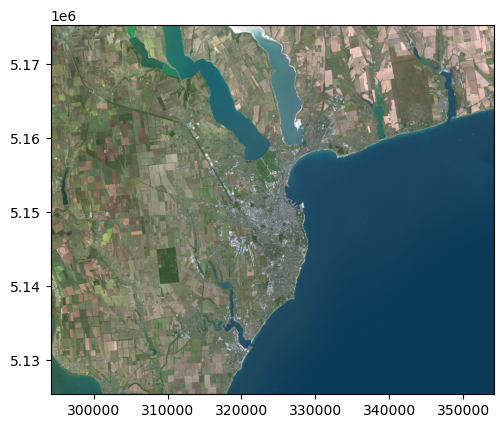

<Axes: >

In [19]:
ds_rasterio = rasterio.open(raster_path)
show(ds_rasterio)

In [2]:
#path to the vector object
vector_path = "../data/odessa_water_poly.shp"

### • rasterio

With rasterio, we will use the *rasterize()* function : https://rasterio.readthedocs.io/en/latest/api/rasterio.features.html#rasterio.features.rasterize

==TO BE COMPLETED==

### • rioxarray

With rioxarray, we can use the geocube library and especially the *geocube.make_geocube()* function : https://corteva.github.io/geocube/html/geocube.html

==TO BE COMPLETED==

### • geoutils

With geoutils, we will use the *rasterize()* function : https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Vector.rasterize.html#geoutils.Vector.rasterize

In this example, we will transform water polygons (.shp) of Odessa region (Ukraine) to rasters.

In [6]:
gu_rast = gu.Raster(raster_path)

gu_vect = gu.Vector(vector_path)

If we plot our polygons above the raster :

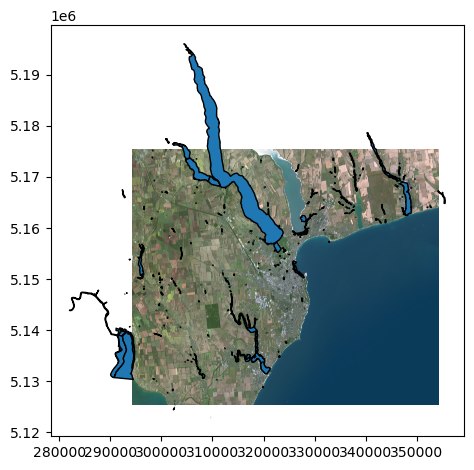

In [11]:
gu_rast.plot()
gu_vect.plot(ref_crs=gu_rast, ec="k", lw=1)

Next we use the *.rasterize()* function :

In [18]:
vect_rasterized = gu_vect.rasterize(gu_rast, in_value=1) #in_value = 1 to burn a single value

If we plot the map, here is the result, focused on our area of study :

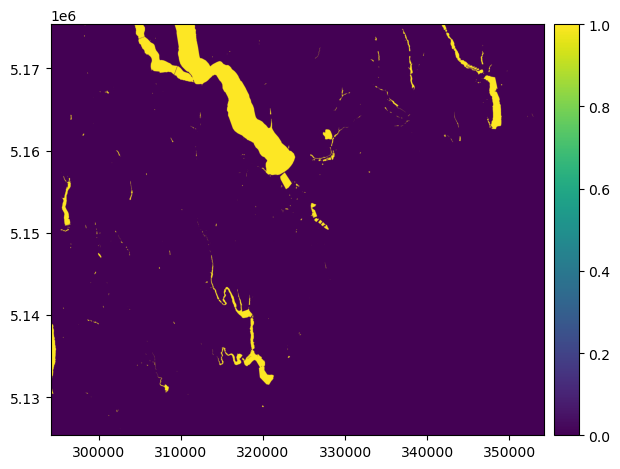

In [20]:
vect_rasterized.plot(ax="new", cmap="viridis")

## Vectorize a raster

### • rasterio

https://rasterio.readthedocs.io/en/latest/topics/features.html#vector-features

==TO BE COMPLETED==

### • rioxarray

For rioxarray, we will use again the geocube library and especially the *geocube.vectorize()* function : https://corteva.github.io/geocube/html/geocube.html#geocube.vector.vectorize

In this example we will focus on a small area (north of Sardinia) to reduce processing times.

In [21]:
#path to the raster object
raster_path = "../data/sard_2.tif"

In [22]:
da_rxr = rioxarray.open_rasterio(raster_path)

We now use the *vectorize()* function from geocube :

In [23]:
da_rxr_vectorized = vectorize(da_rxr)

c:\Users\cbernaert\AppData\Local\anaconda3\envs\open_source_rasters_comparison\Lib\site-packages\geocube\vector.py:62: UserWarning: The array has no name. Column name defaults to _data
  warnings.warn("The array has no name. Column name defaults to _data")


We can plot the result :

<Axes: >

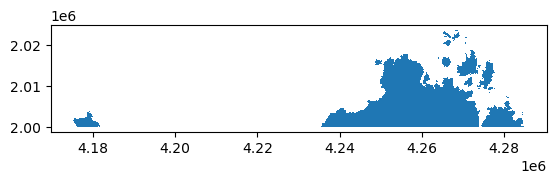

In [24]:
da_rxr_vectorized.plot()

### • geoutils

With geoutils, we will use the *polygonize()* function : https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.polygonize.html#geoutils.Raster.polygonize

In [27]:
gu_rast = gu.Raster(raster_path)

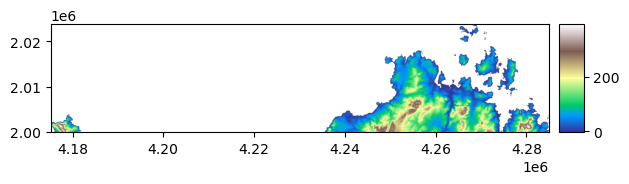

In [28]:
gu_rast.plot(cmap="terrain")

Here we call the function :

In [29]:
rast_polygonized = gu_rast.polygonize()

c:\Users\cbernaert\AppData\Local\anaconda3\envs\open_source_rasters_comparison\Lib\site-packages\numpy\ma\core.py:509: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
c:\Users\cbernaert\AppData\Local\anaconda3\envs\open_source_rasters_comparison\Lib\site-packages\geoutils\interface\raster_vector.py:100: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


And finally the result :

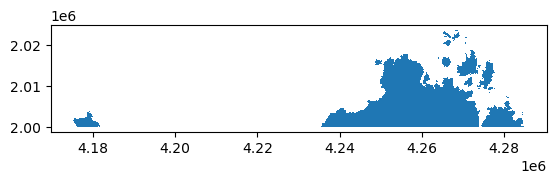

In [30]:
rast_polygonized.plot(ax="new")